# SIMULACIÓN DE MONTECARLO

El DCF entregó un número. Ese número salió de supuestos que pueden estar equivocados. Monte Carlo reemplaza cada supuesto por un rango y prueba miles de combinaciones. El resultado no es un valor sino una distribución de valores con sus probabilidades. Es la respuesta honesta a que la valoración tuvo supuestos inciertos.

1. DE 3 A 5 SUPUESTOS INCIERTOS, LOS QUE DE VERDAD CAMBIAN EL VALOR:

| Supuesto | Base | Rango | Efecto en el patrimonio |
|---|---|---|---|
| Margen operativo | 6.45% | 4.93% - 7.66% | -2,617 a 3,993 |
| Crecimiento | 3.0% | 0% - 5% | 1,591 a 632 |
| Costo de capital | 12.34% |  | endógeno |

2. DISTRIBUCIÓN A CADA UNO:

Triangular cuando hay un valor central creíble y límites conocidos, uniforme cuando solo se conocen los límites.

3. IDENTIFICAR SUPUESTOS QUE SE MUEVEN JUNTOS PARA EVITAR ESCENARIOS IMPOSIBLES:

Margen y wacc:
Si la simulación "sortea" un margen alto y al mismo tiempo un costo de capital alto, se tiene una combinación imposible, pues un margen mas grande eleva la cobertura de intereses, lo que al mismo tiempo mejora el rating sintetico y abarata la deuda.

para no correlacionar estos dos supuestos se toma el costo de capital endogeno. Es decir, en cada iteración, sortear el margen, calcular la cobertura, derivar el rating y el spread con la función que ya tiene, y de ahí el WACC.

**4. Correr la simulación.** Diez mil rondas. En cada una se sortea un valor de cada rango, se calcula el DCF completo y se guarda el resultado. La mediana debería parecerse al caso base

La simulación corre sobre la **estructura de capital actual**

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.costo_capital import rating_sintetico, reapalancar_beta, convertir_tasa

rng = np.random.default_rng(42)
N = 10_000

# añobase
ingresos_base = 38082.2
tasa_mx = 0.30

#balance
deuda = 15935.7
efectivo = 1383.0
acciones = 555980425
precio_mercado = 11.89
gasto_intereses_usd = 1498.0

# costo decapital
beta_desapalancado = 0.793
rf_usd = 0.0443
erp_total = 0.0682
spread_mexico = 0.0152
infl_mxn, infl_usd = 0.0375, 0.0225
rf_mxn = 0.0596

# estructura actual
patrimonio_mercado = precio_mercado * acciones / 1e6
ratio_deuda = deuda / (deuda + patrimonio_mercado)

# proyección
años = 5
roc_inicial = 0.0597
roc_final = 0.0835
wacc_estable = 0.1049
roc_estable = 0.1049

print(f"Ratio de deuda : {ratio_deuda:.1%}")
print(f"Iteraciones    : {N:,}")

Ratio de deuda : 70.7%
Iteraciones    : 10,000


In [2]:
def valor_operacion(margen, g, ratio, deuda_para_cobertura):
    """Valor de la operacion bajo una estructura de capital dadaa"""
    ebit = ingresos_base * margen
    nopat = ebit * (1 - tasa_mx)

    interes = gasto_intereses_usd * deuda_para_cobertura / deuda
    _, spread = rating_sintetico(ebit / interes)
    kd = convertir_tasa(rf_usd + spread_mexico + spread, infl_mxn, infl_usd)

    de = ratio / (1 - ratio)
    beta = reapalancar_beta(beta_desapalancado, de, tasa_mx)
    ke = convertir_tasa(rf_usd + beta * erp_total, infl_mxn, infl_usd)
    wacc = ke * (1 - ratio) + kd * (1 - tasa_mx) * ratio

    if wacc <= g:
        return np.nan

    vp = 0.0
    for a in range(1, años + 1):
        roc = roc_inicial + (roc_final - roc_inicial) * (a - 1) / (años - 1)
        n = nopat * (1 + g) ** a
        vp += n * (1 - g / roc) / (1 + wacc) ** a
        if a == años:
            n_final = n

    vt = n_final * (1 + g) * (1 - g / roc_estable) / (wacc_estable - g)
    return vp + vt / (1 + wacc) ** años


def patrimonio(margen, g, ratio, deuda_cobertura):
    """Puente al patrimonio. Resta siempre la deuda actual: comparar estructuras
    no supone que la empresa repague deuda sin costo"""
    return valor_operacion(margen, g, ratio, deuda_cobertura) + efectivo - deuda

In [3]:
deuda_optima = 0.35 * (deuda + precio_mercado * acciones / 1e6)

print(f"Deuda actual : {deuda:,.1f}")
print(f"Deuda optima : {deuda_optima:,.1f}")
print()
print(f"Caso base, estructura actual : {patrimonio(0.0645, 0.030, ratio_deuda, deuda):,.1f}   (185.9)")
print(f"Caso base, estructura optima : {patrimonio(0.0645, 0.030, 0.35, deuda_optima):,.1f}   (1,063.0)")

Deuda actual : 15,935.7
Deuda optima : 7,891.2

Caso base, estructura actual : 183.6   (185.9)
Caso base, estructura optima : 945.7   (1,063.0)


El caso base de la función da 183.6 contra los 185.9 de modulos anteriores. La diferencia de 1.2% viene del redondeo del ratio de deuda; la simulación lo calcula desde el precio y las acciones, con más decimales. Con estructura óptima da 945.7 contra 1,063.0. La diferencia de 117 es unacorrección, no un error: aquí la cobertura de intereses también mejora al
bajar la deuda.

## Distribuciones

Triangular para los dos: se conocen el mínimo, el máximo y el valor más probable. 

El crecimiento lleva techo en la tasa libre de riesgo de 5.96%. Con máximo de 5% nunca se activa, pero debe estar.

In [4]:
def triangular(minimo, moda, maximo, n=N):
    return rng.triangular(minimo, moda, maximo, n)

margen = triangular(0.0493, 0.0645, 0.0766)
g = np.minimum(triangular(0.000, 0.030, 0.050), rf_mxn)

print(f"Margen  media {margen.mean():.2%}  p10 {np.percentile(margen,10):.2%}  p90 {np.percentile(margen,90):.2%}")
print(f"g       media {g.mean():.2%}  p10 {np.percentile(g,10):.2%}  p90 {np.percentile(g,90):.2%}")

Margen  media 6.34%  p10 5.58%  p90 7.08%
g       media 2.68%  p10 1.24%  p90 4.00%


In [5]:
val_actual = np.array([
    patrimonio(m, gi, ratio_deuda, deuda) for m, gi in zip(margen, g)
])
val_optima = np.array([
    patrimonio(m, gi, 0.35, deuda_optima) for m, gi in zip(margen, g)
])

comp = pd.DataFrame({
    "estructura actual": val_actual,
    "estructura optima": val_optima,
})

resumen = pd.DataFrame({
    "mediana": comp.median(),
    "media": comp.mean(),
    "desv_est": comp.std(),
    "p10": comp.quantile(0.10),
    "p90": comp.quantile(0.90),
    "P(negativo)": (comp < 0).mean(),
    "P(< mercado)": (comp < precio_mercado * acciones / 1e6).mean(),
})
resumen.round(3)

,mediana,media,desv_est,p10,p90,P(negativo),P(< mercado)
estructura actual,43.649,-215.151,1598.525,-2688.653,1692.776,0.489,1.0
estructura optima,791.128,732.485,1416.969,-1239.061,2600.035,0.300,1.0


### Dos estructuras

| | Actual | Óptima |
|---|---|---|
| Mediana | 43.6 | 791.1 |
| Media | -215.2 | 732.5 |
| Desviación estándar | 1598.5 | 1417.0 |
| p10 | -2,688.7 | -1,239.1 |
| p90 | 1692.8 | 2600.0 |
| P(negativo) | 48.9% | 30% |

Desapalancar mejora las dos cosas: el valor esperado sube y el riesgo baja. La probabilidad de que el patrimonio no valga nada cae de 49% a 30%.

Lo más claro está en el p10:El escenario malo se vuelve menos malo, porque con menos deuda un margen bajo ya no arrastra ambién la cobertura, el rating y el costo de capital.

En ninguna de las diez mil simulaciones, con ninguna estructura, el valor llega a 11.89. 

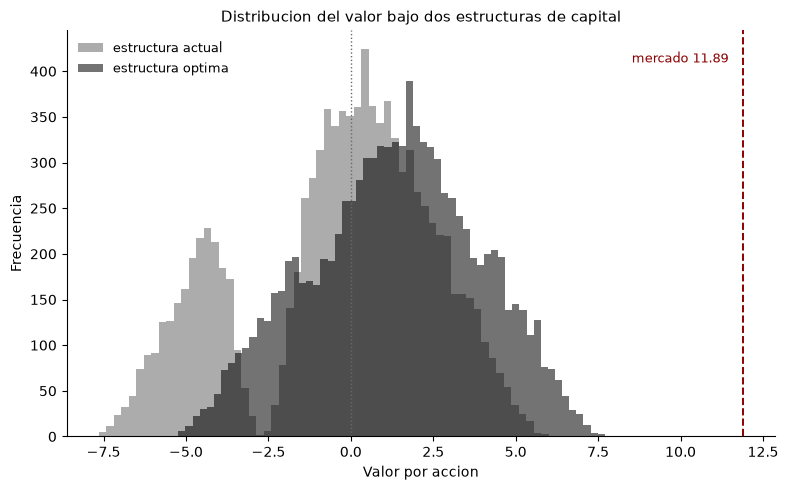

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(val_actual * 1e6 / acciones, bins=60, color="gray",
        alpha=0.65, label="estructura actual", edgecolor="none")
ax.hist(val_optima * 1e6 / acciones, bins=60, color="black",
        alpha=0.55, label="estructura optima", edgecolor="none")

ax.axvline(0, color="dimgray", linewidth=1, linestyle=":")
ax.axvline(precio_mercado, color="darkred", linewidth=1.4, linestyle="--")
ax.annotate(f"mercado {precio_mercado:.2f}",
            (precio_mercado, ax.get_ylim()[1] * 0.92),
            textcoords="offset points", xytext=(-80, 0),
            fontsize=9, color="darkred")

ax.set_xlabel("Valor por accion")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribucion del valor bajo dos estructuras de capital", fontsize=11)
ax.legend(frameon=False, fontsize=9)

for lado in ["top", "right"]:
    ax.spines[lado].set_visible(False)

plt.tight_layout()
plt.savefig("../docs/img/distribucion_valor.png", dpi=150, bbox_inches="tight")
plt.show()

Las dos distribuciones se solapan bastante: el desplazamiento a la derecha existe pero no es dramático. Desapalancar mueve el centro unos 1.3 pesos por acción

Lo que sí cambia visiblemente es la cola izquierda. La distribución con estructura óptima está más recogida, sobre todo en la parte negativa, que es el efecto de quitar el amplificador del apalancamient.

La brecha con el mercado no es un problema de estructura de capital: está en los supuestos operativos.

In [7]:
base = patrimonio(0.0645, 0.030, ratio_deuda, deuda)
abajo = patrimonio(0.0493, 0.030, ratio_deuda, deuda)
arriba = patrimonio(0.0766, 0.030, ratio_deuda, deuda)

print(f"Margen 4.93% : {abajo:>9,.1f}   ({abajo - base:>+9,.1f})")
print(f"Margen 6.45% : {base:>9,.1f}")
print(f"Margen 7.66% : {arriba:>9,.1f}   ({arriba - base:>+9,.1f})")
print()

Margen 4.93% :  -4,096.1   ( -4,279.7)
Margen 6.45% :     183.6
Margen 7.66% :   2,948.0   ( +2,764.5)



### El apalancamiento hace asimétrico el valor

El margen golpea por dos vías a la vez: reduce el EBIT y empeora la cobertura, lo que encarece la deuda y el costo de capital. Con 70.7% de
deuda esa segunda vía amplifica la primera.

El sobreapalancamiento no solo baja el valor. También concentra probabilidad en la cola mala.